
# k-Nearest Neighbors

Sample usage of k-Nearest Neighbors for classification, regression and search.

# Step 1. Business Understanding – IRIS Dataset

The Iris dataset is a classic multivariate dataset introduced by the British biologist and statistician Ronald A. Fisher in 1936. It contains 150 samples of iris flowers from three different species: Iris setosa, Iris versicolor, and Iris virginica. Each sample includes four features: sepal length, sepal width, petal length, and petal width. The goal is to develop a system, that automatically identifies the species of an iris flower based on these physical attributes.

## Determine Business Objectives / Data Mining Goals

- **Objectives**:
  - **Classification**: Accurately classify iris flowers into one of the three species based on its measurable attributes.
  - **Regression**: Predict petal length of an iris flower based on its remaining features with high accuracy.
  - **Search**: Find similar instances of iris flowers based on an example data point.

## Assess Situation

### **Resources:**  
- **IRIS dataset**, consisting of:  
  - **Features**:
    - **Sepal Length** (cm)
    - **Sepal Width** (cm)
    - **Petal Length** (cm)
    - **Petal Width** (cm)
  - **Target**:
    - **Species**: Iris setosa, Iris versicolor, Iris virginica
- **Data Source:**  
  - scikit-learn library: https://scikit-learn.org/stable/datasets/toy_dataset.html

### **Constraints:**
- **Small Sample Size**: Only 150 instances, which limits the complexity of models and may cause overfitting.
- **Limited Features**: Only four simple numeric measurements.
- **Potential Redundancy**: Some features might be highly correlated (e.g., petal length and petal width), which might impact model interpretability.

## Project Plan

### **Deliverables:**

- **Short Feature Exploration & Visualization**: Visualize and identify the most informative features.  
- **Classification Model (kNN)**: Build a kNN classifier and visualize its decision boundaries.  
- **Regression Model (kNN)**: Predict a feature using kNN regression and visualize the predicted values.  
- **Search Model (kNN)**: Implement a kNN-based similarity search with visualized results.  


# Step 2: Data Understanding / Exploratory Data Analysis (EDA)

## Load Libraries

In [11]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import make_pipeline
from IPython.display import display

## Collect Initial Data

Documentation:  
https://en.wikipedia.org/wiki/Iris_flower_data_set  
https://scikit-learn.org/stable/datasets/toy_dataset.html  
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

In [12]:
# The data is loaded as a dictionary with the keys 'data', 'feature_names' and 'target'.
iris = datasets.load_iris()

# Load the data into a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = iris.target_names[df['species']]

In [13]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


## Describe Data

In [21]:
# display columns, missing values and dtypes
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

In [27]:
empty_columns = df.empty
print(empty_columns)

False


- **Features**:
    - 'sepal length (cm)'
    - 'sepal width (cm)'
    - 'petal length (cm)'
    - 'petal width (cm)'
- **Targets**:
    - 'species'
    - 'species_name'

In [15]:
# another way to check for missing values
...

In [16]:
# quick summary statistics
...

## Explore Data

<Axes: >

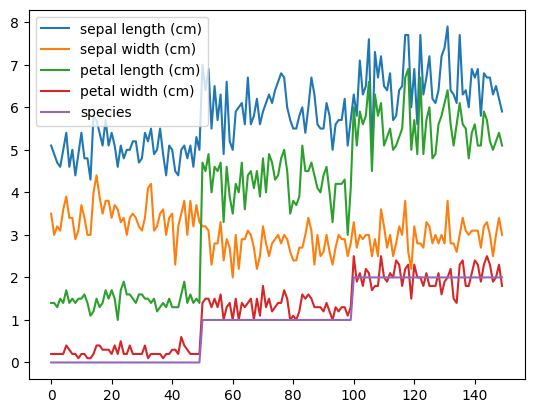

In [17]:
# Quick and dirty plot

df.plot()

In [18]:
px.scatter(
    df,
    x=...,
    y=...,
    color=...,
    width=600,
    height=400,
    template='simple_white',
)

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species', 'species_name'] but received: Ellipsis

**Observations:**
- *petal width* and *petal length* show the strongest and clearest changes with the target
- *setosa* can be clearly identified with just these two features
- *versicolor* and *viginica* are well separated but also show some overlaps $\rightarrow$ for better classification, additional features might be needed
    

# a) kNN Classification

## Step 3: Data Preparation

Quick pandas tutorial: https://pandas.pydata.org/docs/user_guide/10min.html  
Comprehensive pandas tutorial: https://www.youtube.com/playlist?list=PL-osiE80TeTsWmV9i9c58mdDCSskIFdDS

In [ ]:
# For demonstration purposes to show the effect of the Standard Scaler:
df['petal length (mm)'] = df['petal length (cm)'] * 10

In [ ]:
# Select features for classification
features = ['petal length (cm)', 'petal width (cm)']  # 'sepal length (cm)', 'sepal width (cm)'  --> try out different features and see how results change
target = 'species'

# Split dataset into data X and target y
X = ...
y = ...

## Step 4: Modeling

### Build Model

Documentation:  
https://scikit-learn.org/stable/modules/compose.html#pipeline  
https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html  
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

Benefits of using pipelines:
- retain original (untransformed) data for plotting
- compact (all transformations in one onject)
- secure (avoids data leakage between train and test set)

In [ ]:
pipe = make_pipeline(
    KNeighborsClassifier(n_neighbors=3)
)
knn_clf = pipe.fit(X, y)


NameError: name 'X' is not defined

### Assess Model

We are here assessing the model just by visualizing the resulting decision boundaries. You will learn more ways to assess model quality in later lectures.

Documentation:  
https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html  
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html

In [ ]:
fig = plt.figure()
DecisionBoundaryDisplay.from_estimator(knn_clf, X, plot_method="pcolormesh", alpha=0.7)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=iris.target, edgecolor="black")
plt.title("kNN classification of IRIS dataset")
plt.show()

NameError: name 'knn_clf' is not defined

<Figure size 640x480 with 0 Axes>

<div class="alert alert-block alert-info">
    <b>Observe the decision boundaries closely:</b><br>
    What might be (unexpected) pitfalls or limitations of the model with regard to the results it is giving?
</div>

# b) kNN Regression

As example for a regression task, we are using the 'sepal length (cm)' as target, i.e., we want to infer the sepal length based on the petal length and the petal width.

## Step 3: Data Preparation

Quick pandas tutorial: https://pandas.pydata.org/docs/user_guide/10min.html  
Comprehensive pandas tutorial: https://www.youtube.com/playlist?list=PL-osiE80TeTsWmV9i9c58mdDCSskIFdDS

In [ ]:
# Select features for regression
features = ['petal width (cm)', 'sepal length (cm)']  # 'petal length (cm)', 'sepal width (cm)'  --> try out different features and see how results change
target = ['petal length (cm)']  # we are now using the sepal length as target

# split dataset into data X and target y
X = df[features]
y = df[target]

## Step 4: Modeling

### Build Model

Documentation:  
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

In [ ]:
pipe = make_pipeline(
    ...
)
knn_reg = pipe.fit(X, y)

### Assess Model

In regression tasks, we don't have clear cut decision boundaries, since we are not infering one of a fixed number of classes, but a numeric value that can be any real number. Visualizing these is a bit more complicated. It involves to first create a grid of numbers for the features that we then predict the values for (first cell below) and then visualizing these values as a contour-plot (second cell below).

In [19]:
feature_x = np.linspace(X.iloc[:, 0].min(), X.iloc[:, 0].max(), 100)
feature_y = np.linspace(X.iloc[:, 1].min(), X.iloc[:, 1].max(), 100)
dim1, dim2 = np.meshgrid(feature_x, feature_y)
grid = np.stack([dim1.ravel(), dim2.ravel()], axis=1)
df_grid = pd.DataFrame(grid, columns=X.columns)
grid_prediction = knn_reg.predict(df_grid).reshape(dim1.shape)

NameError: name 'knn_reg' is not defined

In [ ]:
fig = plt.figure()
plt.contourf(dim1, dim2, grid_prediction, alpha=0.8)
cbar = plt.colorbar()
cbar.ax.set_ylabel(y.columns[0])
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=iris.target, edgecolor="black")
plt.title(f"kNN regression of {y.columns[0]}")
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.show()

# c) kNN Search

As example for a search task, we are trying to find three instances of plants with similar petal width and sepal length as we are giving.

## Step 3: Data Preparation

For search, we actually don't need a target, since the result are the data points themselves.

In [ ]:
features = ['petal width (cm)', 'sepal length (cm)']  # 'petal length (cm)', 'sepal width (cm)'  --> try out different features and see how results change
X = df[features]
X

## Step 4: Modeling

### Build Model

Documentation:  
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html

In [ ]:
pipe = make_pipeline(
    ...
)
knn_search = pipe.fit(X)

### Assess Model

In [ ]:
# Create dataframe with new example values for the two features
sample_df = pd.DataFrame([[0.5, 5.0], [1.4, 6.2], [2.3, 6.5]], columns=features)

Since the pipeline object only has a 'predict' function itself but not a 'kneighbors' function, we need to call the steps of the pipeline manually here and call 'kneighbors' on the last step of the pipeline (which is our NearestNeighbors model). You can display the names of the steps by calling knn_search.named_steps (where nn is the name of the pipeline)

In [ ]:
# Transform and find nearest neighbors
transformed_data_point = knn_search.named_steps['standardscaler'].transform(sample_df)
distances, indices = knn_search.named_steps['nearestneighbors'].kneighbors(transformed_data_point, n_neighbors=3)

In [ ]:
display(sample_df)
# iterate over the found indices of nearest neighbors to display these data points from the training data set
columns = ['petal width (cm)', 'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'species_name']
for idx in indices:
    display(df.iloc[idx].loc[:, columns])

In [ ]:
# visualize the data set (filled circles), the example data points (bigger, unfilled circles) and
# the returned nearest neighbors (colored crosses)
fig = plt.figure()
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=iris.target, edgecolor="black")
plt.scatter(sample_df.iloc[:, 0], sample_df.iloc[:, 1], color="white", edgecolor="black", linewidths=2, s=100)
for idx in indices:
    plt.scatter(X.iloc[idx, 0], X.iloc[idx, 1], marker='x', linewidths=2, s=200)
plt.title("kNN search of IRIS dataset")
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.show()